#### Problem statement : We are making a chatbot that can give answers that based on youtube video

- Chrome Plugin
- Strealit
##### UI can be anything u want

Plan of Action :
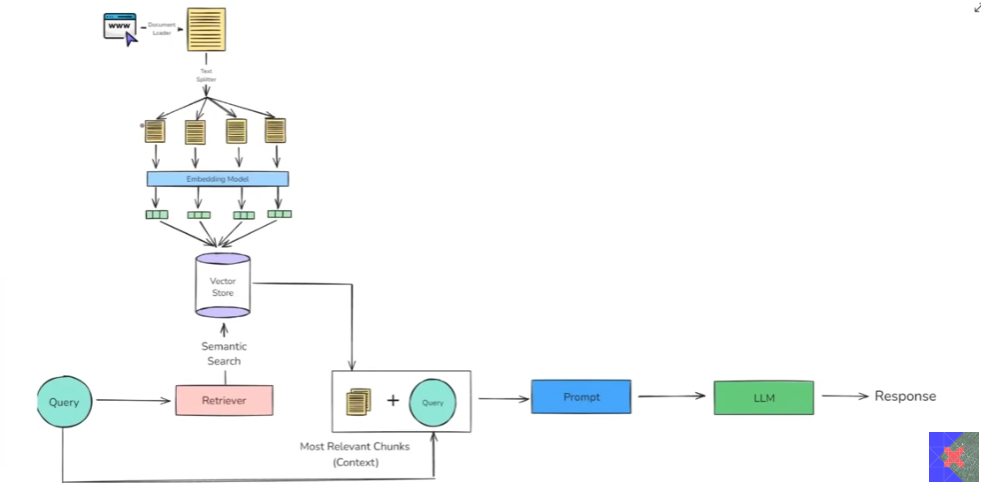 

In [7]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from langchain_community.vectorstores import FAISS
from langchain_core.runnables import RunnableParallel, RunnableSequence, RunnableLambda
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv 
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api._errors import TranscriptsDisabled


embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
)

load_dotenv()

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9141.59it/s]


### Step 1a - Indexing(Document Ingestion)

In [13]:
video_id = 'Gfr50f6ZBvo'
try:
    api = YouTubeTranscriptApi()
    transcript_list = api.fetch(video_id, languages=['en'])
    
    transcript = " ".join(chunk.text for chunk in transcript_list)
    print(transcript)

except TranscriptsDisabled:
    print("No Caption available for this video")


the following is a conversation with demus hasabis ceo and co-founder of deepmind a company that has published and builds some of the most incredible artificial intelligence systems in the history of computing including alfred zero that learned all by itself to play the game of gold better than any human in the world and alpha fold two that solved protein folding both tasks considered nearly impossible for a very long time demus is widely considered to be one of the most brilliant and impactful humans in the history of artificial intelligence and science and engineering in general this was truly an honor and a pleasure for me to finally sit down with him for this conversation and i'm sure we will talk many times again in the future this is the lex friedman podcast to support it please check out our sponsors in the description and now dear friends here's demis hassabis let's start with a bit of a personal question am i an ai program you wrote to interview people until i get good enough 

In [12]:
transcript_list

FetchedTranscript(snippets=[FetchedTranscriptSnippet(text='Imagine you happen across a short movie script that', start=1.14, duration=2.836), FetchedTranscriptSnippet(text='describes a scene between a person and their AI assistant.', start=3.976, duration=3.164), FetchedTranscriptSnippet(text="The script has what the person asks the AI, but the AI's response has been torn off.", start=7.48, duration=5.58), FetchedTranscriptSnippet(text='Suppose you also have this powerful magical machine that can take', start=13.06, duration=3.92), FetchedTranscriptSnippet(text='any text and provide a sensible prediction of what word comes next.', start=16.98, duration=3.98), FetchedTranscriptSnippet(text='You could then finish the script by feeding in what you have to the machine,', start=21.5, duration=4.006), FetchedTranscriptSnippet(text="seeing what it would predict to start the AI's answer,", start=25.506, duration=2.862), FetchedTranscriptSnippet(text='and then repeating this over and over with 

In [15]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
chunks = splitter.create_documents([transcript])

In [16]:
len(chunks)

168

In [17]:
chunks[167]

Document(metadata={}, page_content='demas establish to support this podcast please check out our sponsors in the description and now let me leave you with some words from edskar dykstra computer science is no more about computers than astronomy is about telescopes thank you for listening and hope to see you next time')

In [18]:
# Embeddings
embeddings

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [19]:
vector_store = FAISS.from_documents(chunks, embeddings)

In [22]:
vector_store

In [23]:
# Step 2 : Retrieval

retriever = vector_store.as_retriever(search_type = "similarity", search_kwargs={"k":4})

In [24]:
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000029A0D72EF90>, search_kwargs={'k': 4})

In [25]:
retriever.invoke('What is Deepmind')

[Document(id='5e5495b2-7057-4687-9e6c-b7ecae6a0a2a', metadata={}, page_content="and how it works this is tough to uh ask you this question because you probably will say it's everything but let's let's try let's try to think to this because you're in a very interesting position where deepmind is the place of some of the most uh brilliant ideas in the history of ai but it's also a place of brilliant engineering so how much of solving intelligence this big goal for deepmind how much of it is science how much is engineering so how much is the algorithms how much is the data how much is the hardware compute infrastructure how much is it the software computer infrastructure yeah um what else is there how much is the human infrastructure and like just the humans interact in certain kinds of ways in all the space of all those ideas how much does maybe like philosophy how much what's the key if um uh if if you were to sort of look back like if we go forward 200 years look back what was the key 

In [27]:
# Augmentation
prompt = PromptTemplate(
    template= """
    You are a helpful assistant.Answer only from the provided transcipt context. If the context is not sufficient, just say you dont know.
    {context}
    Question : {question}
    """,
    input_variables = ['context', 'question']
    
)

In [28]:
question = "Is the topic od aliens discussed in this video? if yes then what was discussed"
retrieved_docs = retriever.invoke(question)

In [29]:
retrieved_docs

[Document(id='fff7c57f-d997-47c1-a95e-f9e58fc02e0f', metadata={}, page_content="space age we should have heard a cacophony of voices we should have joined that cacophony of voices and what we did we opened our ears and we heard nothing and many people who argue that there are aliens would say well we haven't really done exhaustive search yet and maybe we're looking in the wrong bands and and we've got the wrong devices and we wouldn't notice what an alien form was like to be so different to what we're used to but you know i'm not i don't really buy that that it shouldn't be as difficult as that like we i think we've searched enough there should be if it were everywhere if it was it should be everywhere we should see dyson's fears being put up sun's blinking in and out you know there should be a lot of evidence for those things and then there are other people argue well the sort of safari view of like well we're a primitive species still because we're not space faring yet and and and we

In [30]:
context_text = "/n/n".join(doc.page_content for doc in retrieved_docs)

In [31]:
final_prompt = prompt.invoke({"context" : context_text, "question" : question})

In [33]:
# Step 4 : generation
answer = model.invoke(final_prompt)
print(answer.content)

Yes, the topic of aliens is discussed in this video. The discussion revolves around whether there are alien civilizations, the possibility of extraterrestrial life, and the likelihood of encountering them. The speaker expresses doubts about the presence of alien life, citing the lack of evidence and the uniformity of the hypothetical alien civilizations' behavior. They also mention the possibility of a violent dictatorship among successful alien civilizations, making it difficult to detect them. The discussion also touches on the idea of the "Great Filter" that might prevent civilizations from becoming multi-planetary or reaching out into the stars.


- Building chain for this
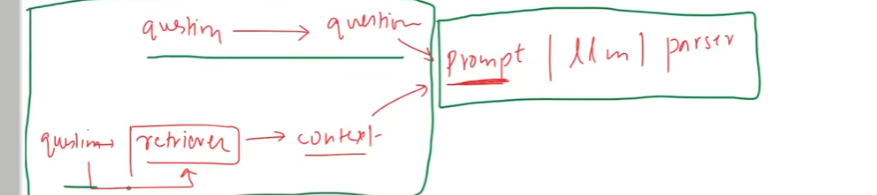

In [35]:
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda 

def format_docs(retrieved_docs):
    context_text = "/n/n".join(doc.page_content for doc in retrieved_docs)
    return context_text

parallel_chain = RunnableParallel({
    'context' : retriever | RunnableLambda(format_docs),
    'question' : RunnablePassthrough()
})

In [36]:
parallel_chain.invoke('who is demis')

{'context': "to get world peace because there's also other corrupting things like wanting power over people and this kind of stuff which is not necessarily satisfied by by just abundance but i think it will help um and i think uh but i think ultimately ai is not going to be run by any one person or one organization i think it should belong to the world belong to humanity um and i think maybe many there'll be many ways this will happen and ultimately um everybody should have a say in that do you have advice for uh young people in high school and college maybe um if they're interested in ai or interested in having a big impact on the world what they should do to have a career they can be proud of her to have a life they can be proud of i love giving talks to the next generation what i say to them is actually two things i i think the most important things to learn about and to find out about when you're when you're young is what are your true passions is first of all there's two things on

In [37]:
parser = StrOutputParser()

main_chain = parallel_chain | prompt | model | parser

In [40]:
main_chain.invoke('Who is demas')

'Demis Hassabis, the CEO and co-founder of DeepMind, a company that has published and built some of the most incredible artificial intelligence systems in the history of computing. He is widely considered to be one of the most brilliant and impactful humans in the history of artificial intelligence and science and engineering in general.'

# Improvements

1. UI based enhancements

2. Evaluations 
    - Ragas
    - LangSmith

3. Indexing
    - Document Ingestion
    - Text splitting
    - Vector Store

4. Retreival
    - Pre-Retreival
        - Query rewriting using LLM
        - Multi Query geenration
        - domain aware routing
    - During Retrieval
        - MMR
        - hybrid Retreival
        - Reranking
    - Post Retrieval
        - Context Compression

5. Augmentation
    - Prompt Templating
    - Answer grounding
    - context window optimization

6. Genration
    - Answer with citation
    - Guard Railing

7. System Design
    - Multimodal
    - Agentic
    - Memory based
